# **Vehicle Feature Clustering**

**Project Type** **: Automotive**

**Project Prepared By : Pranav Thakur**

# **Project Summary**

This project focuses on segmenting vehicles based on their performance and efficiency characteristics using unsupervised machine learning techniques. The dataset contains various features such as MPG, horsepower, weight, and acceleration. Exploratory Data Analysis (EDA) was performed to understand relationships between variables, followed by data preprocessing and feature scaling. K-Means clustering was applied to group similar vehicles, and dimensionality reduction using PCA was used for visualization. The goal was to identify meaningful vehicle segments based on their attributes.

# **Problem Statement**

The objective of this project is to group vehicles into distinct segments based on their characteristics such as fuel efficiency, engine power, and weight. Since no predefined labels are available, an unsupervised learning approach is used. The challenge is to identify natural groupings in the data that can help understand different categories of vehicles, such as fuel-efficient, balanced, and high-performance vehicles.

# **Lets Begin !**

# **Importing Libaries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# **Dataset Loading**

In [2]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"
df = pd.read_csv(url)

df_clean = df.copy()

# **Dataset First Look**

In [3]:
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (398, 9)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


# **Dataset Rows And Columns**

In [4]:
print("Rows & Columns:",
df_clean.shape)

Rows & Columns: (398, 9)


# **Dataset Info**

In [5]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB


# **Statistical Summary**

In [6]:
summary = df_clean.describe()
display(summary)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


# **Duplicate Values**

In [7]:
# Check duplicate rows
duplicate_rows = df_clean.duplicated().sum()
print("Duplicate Rows:", duplicate_rows)

# Check duplicate columns
duplicate_cols = df_clean.columns.duplicated().sum()
print("Duplicate Columns:", duplicate_cols)


Duplicate Rows: 0
Duplicate Columns: 0


# **Missing Values**

In [8]:
df_clean.isnull().sum()

,0
mpg,0
cylinders,0
displacement,0
horsepower,6
weight,0
acceleration,0
model_year,0
origin,0
name,0


# **Data Wrangling**

In [9]:
# Handle missing values
df_clean['horsepower'] = df_clean['horsepower'].fillna(df_clean['horsepower'].median())

# Verify
print(df_clean.isnull().sum())

print("Median:", df_clean['horsepower'].median())


mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64
Median: 93.5


# **Exploratory Data Analysis (EDA)**

# **1️⃣ MPG Distribution**

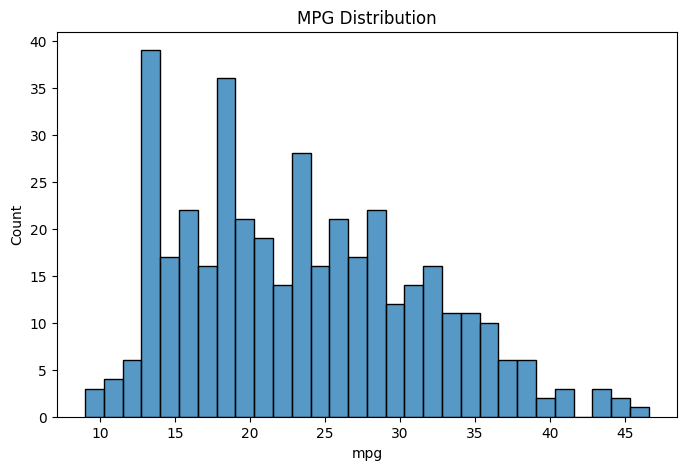

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df_clean['mpg'], bins=30)
plt.title("MPG Distribution")
plt.show()

**Why this chart?**

To understand the spread of fuel efficiency across vehicles.

**What does it show?**

Distribution of MPG values.


**Insight:**

Most vehicles have MPG between 15–30, indicating average fuel efficiency. A few vehicles show high MPG, representing highly efficient cars.

**Analysis:**

The dataset is slightly right-skewed, meaning high-efficiency vehicles are fewer.

# **2️⃣ Horsepower vs MPG**

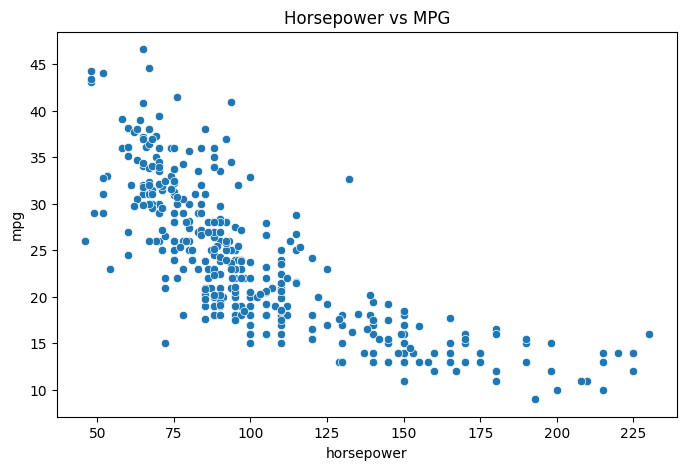

In [11]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='horsepower', y='mpg', data=df_clean)
plt.title("Horsepower vs MPG")
plt.show()

**Why this chart?**

To analyze relationship between engine power and fuel efficiency.

**What does it show?**

Scatter relationship between horsepower and MPG.

**Insight:**

There is a strong negative relationship — as horsepower increases, MPG decreases.

**Analysis:**

Powerful engines consume more fuel, reducing efficiency.

# **3️⃣ Weight vs MPG**

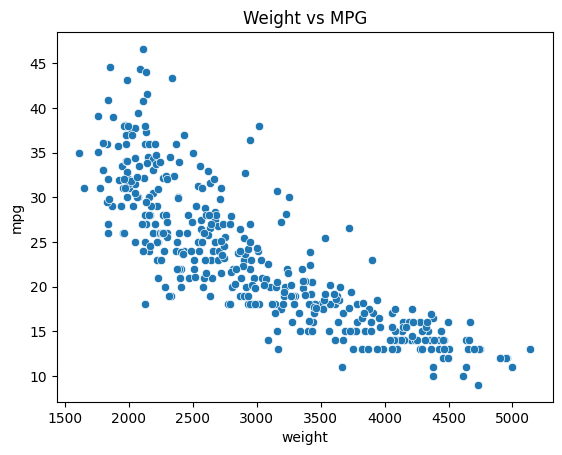

In [12]:
sns.scatterplot(x='weight', y='mpg', data=df_clean)
plt.title("Weight vs MPG")
plt.show()

**Why this chart?**

To study impact of vehicle weight on fuel efficiency.

**What does it show?**

Scatter plot of weight vs MPG.

**Insight:**

Heavier vehicles have lower MPG.

**Analysis:**

Weight is a major factor affecting fuel consumption and efficiency.

# **4️⃣ Correlation Heatmap**

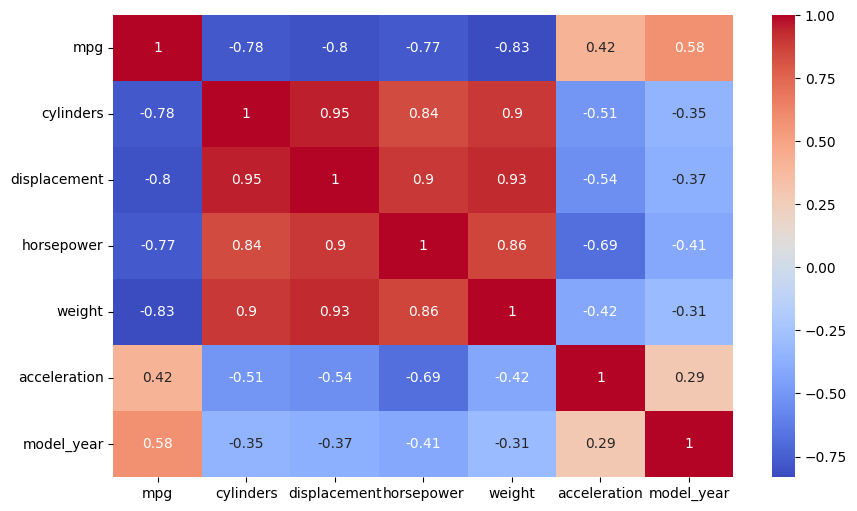

In [13]:
plt.figure(figsize=(10,6))
sns.heatmap(df_clean.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm')
plt.show()

**Why this chart?**

To understand relationships between all numerical features.

**What does it show?**

Correlation values between features.

**Insight:**

**.** MPG negatively correlated with weight & horsepower

**.** Weight and horsepower are positively correlated

**.** Strong relationship between engine size-related features

**Analysis:**

These correlations justify clustering vehicles based on performance and efficiency.

# **5️⃣ Horsepower vs Weight**

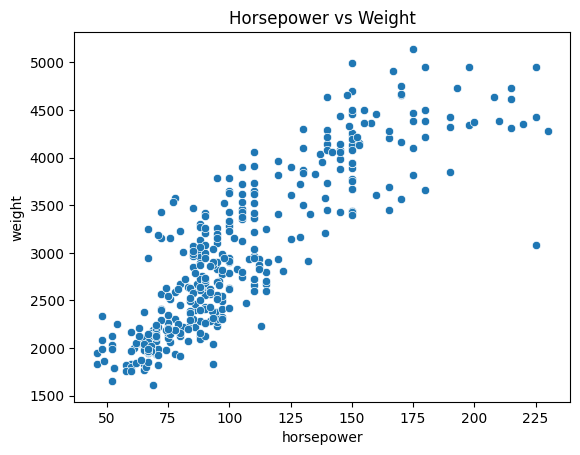

In [14]:
sns.scatterplot(x='horsepower', y='weight', data=df_clean)
plt.title("Horsepower vs Weight")
plt.show()

**Why this chart?**

To analyze the relationship between engine power and vehicle weight.

**What does it show?**

Scatter plot between horsepower and weight.

**Insight:**

There is a positive relationship — vehicles with higher horsepower are generally heavier.

**Analysis:**

More powerful engines are usually installed in larger and heavier vehicles, which explains the strong association between weight and horsepower. This supports clustering based on performance-related features.

# **6️⃣ Cylinders vs MPG (Boxplot)**

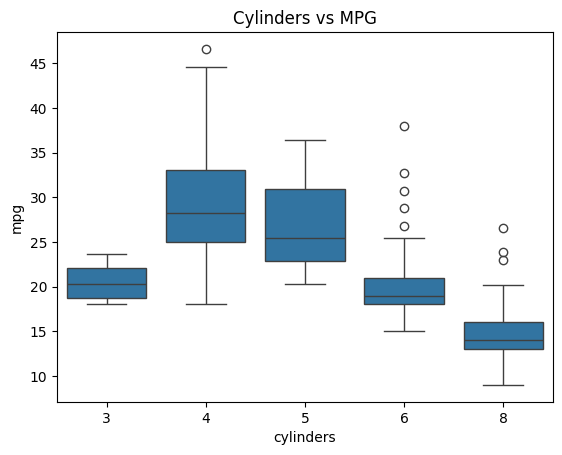

In [15]:
sns.boxplot(x='cylinders', y='mpg', data=df_clean)
plt.title("Cylinders vs MPG")
plt.show()

**Why this chart?**

To analyze how engine size affects mileage.

**What does it show?**

MPG distribution across different cylinder counts.

**Insight:**

Vehicles with more cylinders have lower MPG.

**Analysis:**

Larger engines consume more fuel, reducing efficiency.

# **7️⃣ Acceleration vs Horsepower**

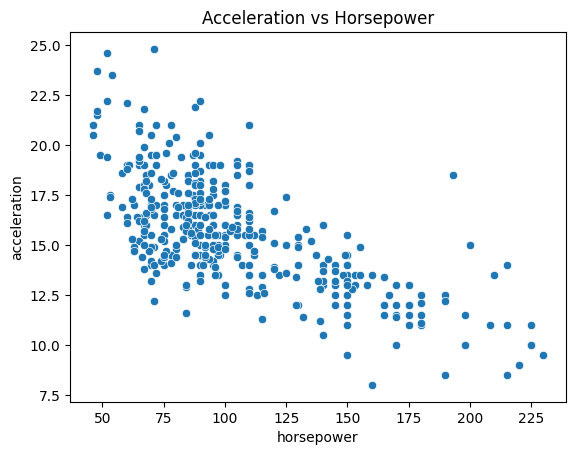

In [16]:
sns.scatterplot(x='horsepower', y='acceleration', data=df_clean)
plt.title("Acceleration vs Horsepower")
plt.show()

**Why this chart?**

To understand how engine power affects vehicle acceleration.

**What does it show?**

Scatter relationship between horsepower and acceleration.

**Insight:**

Vehicles with higher horsepower generally show better acceleration performance, though the relationship is not perfectly linear.

**Analysis:**

Acceleration depends on multiple factors (weight, engine design), but horsepower still plays a key role in improving performance.

# 8️⃣ **Origin vs MPG (Boxplot)**

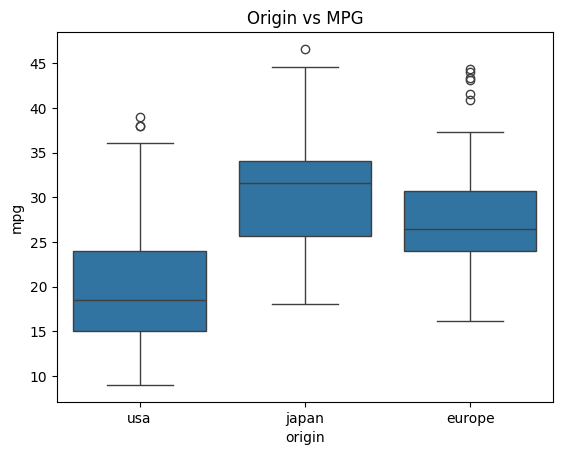

In [17]:
sns.boxplot(x='origin', y='mpg', data=df_clean)
plt.title("Origin vs MPG")
plt.show()

**Why this chart?**

To compare fuel efficiency across regions.

**What does it show?**

MPG variation based on origin.

**Insight:**

European and Japanese cars tend to have higher MPG compared to others.

**Analysis:**

Design differences and engineering standards affect fuel efficiency.

# **Feature Scaling**

In [18]:
X = df_clean.drop(columns=['origin', 'name'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Feature scaling was applied to normalize the data so that all features contribute equally to the clustering process. Scaling ensures that no single feature dominates the clustering results.

# **Elbow Method**

**Why Elbow ?**

The Elbow Method is used to determine the optimal number of clusters in K-Means clustering. It works by plotting the Within-Cluster Sum of Squares (WCSS) for different values of k. The point where the rate of decrease in WCSS slows down significantly (forming an “elbow” shape) is considered the optimal number of clusters.

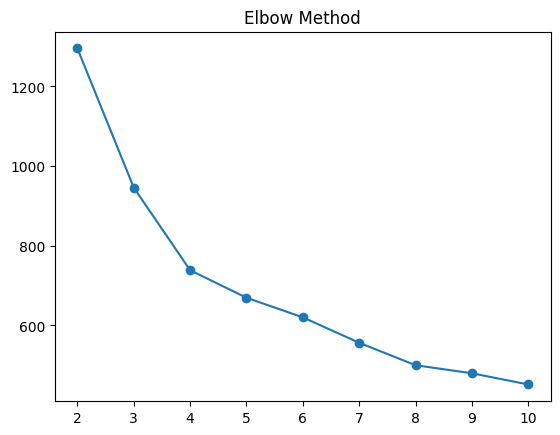

In [19]:
wcss = []

for i in range(2,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(2,11), wcss, marker='o')
plt.title("Elbow Method")
plt.show()

The elbow method suggested a possible range between 2 and 3 clusters, but the silhouette score indicated that k=2 provides better cluster separation.

# **Silhouette Score**

In [20]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)
score = silhouette_score(X_scaled, labels)
print("Silhouette Score:", score)

Silhouette Score: 0.4823594610391611


**The silhouette score indicates moderate clustering quality, suggesting some overlap between clusters but still meaningful grouping.**

# **K-Means Clustering**

In [21]:
kmeans = KMeans(n_clusters=2, random_state=42)
df_clean['Cluster'] = kmeans.fit_predict(X_scaled)

# **PCA (Principal Component Analysis)**

In [22]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)

df_clean['PCA1'] = pca_data[:,0]
df_clean['PCA2'] = pca_data[:,1]

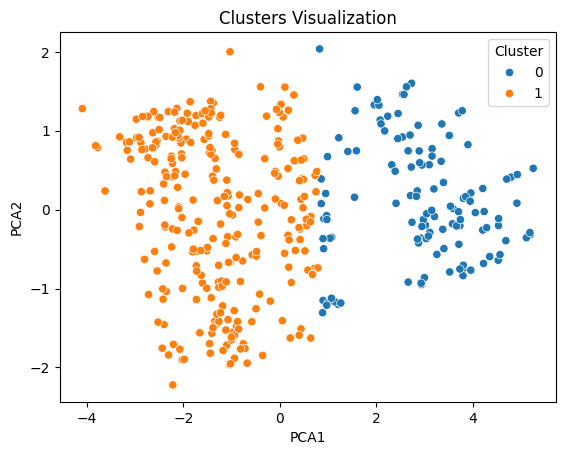

In [23]:
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=df_clean)
plt.title("Clusters Visualization")
plt.show()

**PCA reduced the high-dimensional dataset into two principal components, making cluster visualization easier. The plot shows a clear separation between two major groups of vehicles, with minor overlap in boundary regions. This indicates that the clustering is effective and captures meaningful differences between vehicle types.**

# **Cluster Insights**

In [24]:
df_clean.groupby('Cluster').mean(numeric_only=True)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,PCA1,PCA2
Cluster,,,,,,,,,
0,15.275410,7.672131,328.860656,150.540984,4008.680328,13.360656,73.827869,2.906091,0.120834
1,27.156522,4.474638,133.559783,83.865942,2511.485507,16.543841,76.974638,-1.284576,-0.053412


**Cluster 0: High-performance vehicles with high horsepower, weight, and low MPG.**

**Cluster 1: Fuel-efficient vehicles with lower weight, lower horsepower, and higher MPG.**



# **MODEL TUNING**

**1️⃣ Tuning K using Silhouette Score**

In [25]:
scores = []

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    scores.append(score)
    print(f"k={k}, Silhouette Score={score}")

k=2, Silhouette Score=0.46264452576184095
k=3, Silhouette Score=0.35314791198988205
k=4, Silhouette Score=0.34770360093701747
k=5, Silhouette Score=0.30075044433158277
k=6, Silhouette Score=0.2816014615332966
k=7, Silhouette Score=0.2762034348076627
k=8, Silhouette Score=0.2566099042828498
k=9, Silhouette Score=0.24858422408339478


**2️⃣ Selecting Best K**

In [26]:
best_k = range(2,10)[scores.index(max(scores))]
print("Best K:", best_k)

Best K: 2


**3️⃣ Plot**

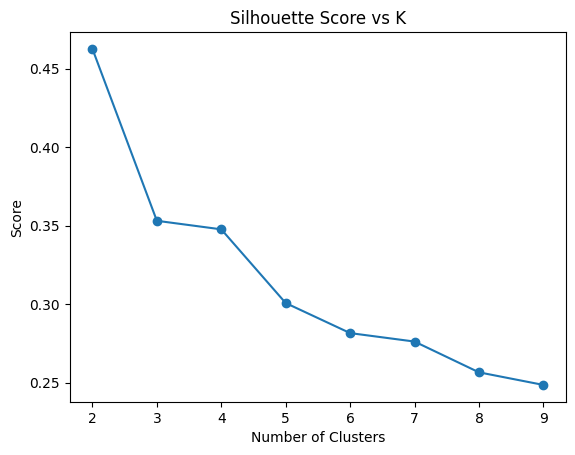

In [27]:
plt.plot(range(2,10), scores, marker='o')
plt.title("Silhouette Score vs K")
plt.xlabel("Number of Clusters")
plt.ylabel("Score")
plt.show()

**Model tuning was performed by testing different values of k. The optimal number of clusters was selected based on the highest silhouette score, ensuring better separation and cohesion.**

# **Final Conclusion**

The project successfully applied K-Means clustering to segment vehicles into distinct groups based on their features. The Elbow Method suggested an optimal number of clusters as 3, while the Silhouette Score indicated better separation at k=2, highlighting moderate cluster structure in the data. PCA visualization showed that clusters are not perfectly separable but still form meaningful groupings. The analysis revealed that vehicles can be broadly categorized into two segments: fuel-efficient and high-performance vehicles.